# Comparison and Testing of BaselineGAT with Custom MPNN
## Loading and split dataset for BaselineGNNs

In [1]:
from atoMLtype.GNN.GNNmodel import BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np
import importlib

[15:49:46] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[15:49:46] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[15:49:46] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[15:49:47] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


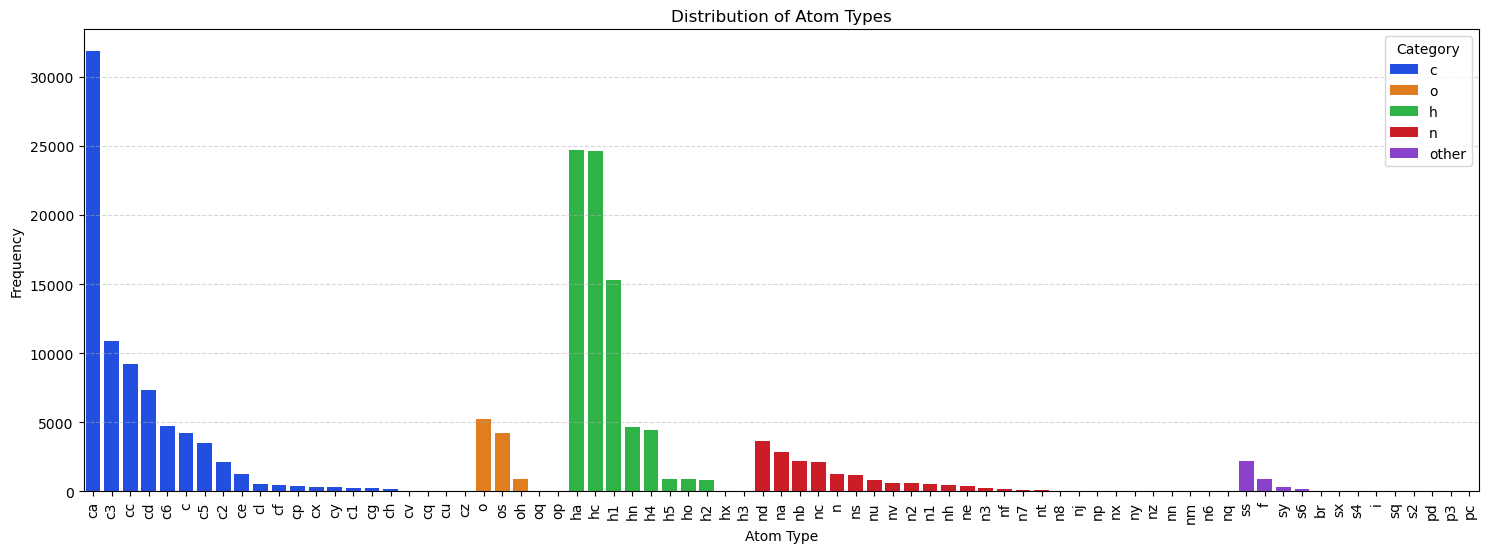

,Atom Type,Count,Category
0,ca,31844,c
1,c3,10858,c
2,cc,9192,c
3,cd,7361,c
4,c6,4704,c
...,...,...,...
70,sq,7,other
71,s2,4,other
72,pd,2,other
73,p3,2,other


In [2]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

## Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

BaselineGCN - Number of parameters: 379467
--- Fold 1/5 ---


Epoch 10: Train Loss = 0.7660, Val Loss = 0.7589
--- Fold 2/5 ---


Epoch 10: Train Loss = 0.6787, Val Loss = 0.6869
--- Fold 3/5 ---


Epoch 10: Train Loss = 0.6316, Val Loss = 0.6767
--- Fold 4/5 ---


Epoch 10: Train Loss = 0.6184, Val Loss = 0.6167
--- Fold 5/5 ---


Epoch 10: Train Loss = 0.6031, Val Loss = 0.5978


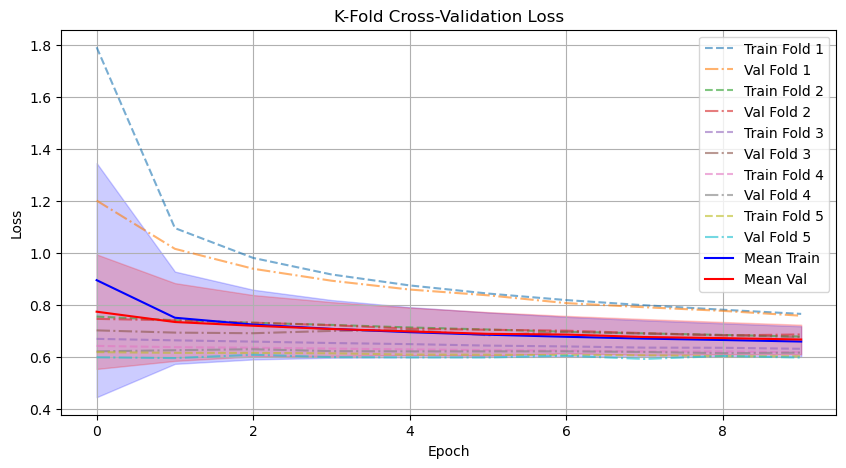

{'train_loss': [[1.792499053494623,
   1.0961712476812662,
   0.9814142593877593,
   0.9177473797066059,
   0.8755450186097193,
   0.8443088017664834,
   0.8191829734809803,
   0.799238575146421,
   0.7819596814298522,
   0.7659884563173933],
  [0.7555817928525178,
   0.7417680290450674,
   0.7319198297455559,
   0.7236586638060196,
   0.7138641365735384,
   0.7058168549333246,
   0.6973010963432765,
   0.6910406272969393,
   0.6849354960666376,
   0.6787403030117518],
  [0.6698973812057861,
   0.6641810978812144,
   0.6593027716975935,
   0.6538767934583575,
   0.6496358247557277,
   0.6439137324694496,
   0.6407648838815098,
   0.6361812220622935,
   0.6356080235224241,
   0.631623941955818],
  [0.6427819477362526,
   0.6379419668269837,
   0.6357005161536646,
   0.6323193820446938,
   0.6293983205629835,
   0.6263452951003825,
   0.6247113928632504,
   0.6213743408913949,
   0.6214045313165216,
   0.6184214511769555],
  [0.6188070695036788,
   0.6160412513682774,
   0.61587840305367

In [5]:
import atoMLtype.utils.output
import atoMLtype.GNN.GNNmodel
import atoMLtype.GNN.trainer
importlib.reload(atoMLtype.utils.output)
importlib.reload(atoMLtype.GNN.GNNmodel)
importlib.reload(atoMLtype.GNN.trainer)
from atoMLtype.GNN.GNNmodel import BaselineGCN
from atoMLtype.GNN.trainer import GNNTrainer
from atoMLtype.engines.ModelEngine import ModelEngine

# Initialize BaselineGCN for classification
model_kfold = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model_kfold, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=10, k_folds=5, random_seed=21)
trainer.train()

BaselineGCN - Number of parameters: 379467


Epochs: 100%|██████████| 10/10 [00:18<00:00,  1.83s/it]

Epoch 10: Train Loss = 0.7449


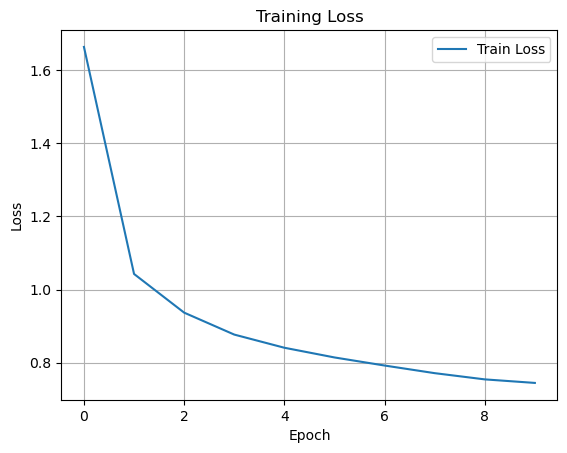

{'train_loss': [1.6634189641302626,
  1.0427777731501857,
  0.9370532716204949,
  0.8770668322298222,
  0.8410838893498667,
  0.8145617956177384,
  0.7924769902554174,
  0.7716239411381195,
  0.7545925719993052,
  0.7449165694527825]}

In [6]:
# Initialize BaselineGCN for classification
model_wo_kfold = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model_wo_kfold, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=10, random_seed=21)
trainer.train()

In [ ]:
import atoMLtype.engines.ModelEngine
importlib.reload(atoMLtype.engines.ModelEngine)
from atoMLtype.engines.ModelEngine import ModelEngine

# Get label encoder from the gnn_test_dataset
model_label_encoder = gnn_test_dataset.label_encoder

modelEngine = ModelEngine(model=model,
                        dataset=test_dataset, 
                        label_encoder=model_label_encoder, 
                        device="cpu", 
                        batch_size=32)

predictionRecord_inf = modelEngine.predict()
predictionRecord_inf.summary()

plot_full_heatmap(y_true=predictionRecord_inf.get_labels('true'), y_pred=predictionRecord_inf.get_labels('pred'))

In [ ]:
predictionRecord_ana = modelEngine.predict(analysis=True)

predictionRecord_ana.summary()

In [ ]:
model_final_embeddings = predictionRecord_ana.get_analysis("final_embeddings")
print(model_final_embeddings)
model_final_labels = predictionRecord_ana.get_labels('true')
print(model_final_labels)

visualize_embeddings(
    model_final_embeddings,
    model_final_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)

true_labels = predictionRecord_ana.get_labels('true')
pred_labels = predictionRecord_ana.get_labels('pred')
mismatches_mask = [t != p for t, p in zip(true_labels, pred_labels)]

visualize_embeddings_mismatches(
    embeddings=model_final_embeddings,
    labels=true_labels,
    mismatches_mask=mismatches_mask,
    pred_labels=pred_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)

# Loading MPNNdataset - Directed Bond Graphs for custom D-MPNN

In [ ]:
from atoMLtype.GNN.GNNdataset import MPNNdataset

In [ ]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
mpnn_test_dataset = MPNNdataset(sdf_path, json_labels, collapse=True)

In [ ]:
# Initialize dataset
num_atom_feat = mpnn_test_dataset[0].x.shape[1]
num_bond_feat = mpnn_test_dataset[0].edge_attr.shape[1]
num_y_ATs = len(set(mpnn_test_dataset.all_labels))

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(mpnn_test_dataset))
test_size = len(mpnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(mpnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(mpnn_test_dataset.all_labels))

print(f"num_atom_features = {num_atom_feat}")
print(f"num_bond_features = {num_bond_feat}")
print(f"num_y_ATs = {num_y_ATs}")

print("Total dataset size:", len(mpnn_test_dataset))
print("Train split size:", len(train_dataset))
print("Test split size:", len(test_dataset))

# Check first few samples from each to ensure they aren't empty
print("First train sample:", train_dataset[0])
print("First test sample:", test_dataset[0])

In [ ]:
from atoMLtype.GNN.MPNNmodel_custom import Att_AtomBondMPNN

model_AtomMPNN = Att_AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_AtomMPNN.train()

In [ ]:
# Get label encoder from the gnn_test_dataset
MPNNNmodel_label_encoder = mpnn_test_dataset.label_encoder

MPNNmodelEngine = ModelEngine(model=model_AtomMPNN,
                        dataset=test_dataset, 
                        label_encoder=MPNNNmodel_label_encoder, 
                        device="cpu", 
                        batch_size=32)

MPNNpredictionRecord_inf = MPNNmodelEngine.predict()
MPNNpredictionRecord_inf.summary()

plot_full_heatmap(y_true=MPNNpredictionRecord_inf.get_labels('true'), y_pred=MPNNpredictionRecord_inf.get_labels('pred'))

In [ ]:
MPNNpredictionRecord_ana = MPNNmodelEngine.predict(analysis=True)

MPNNpredictionRecord_ana.summary()

In [ ]:
model_final_embeddings = MPNNpredictionRecord_ana.get_analysis("clf_embeddings")
print(model_final_embeddings)
model_final_labels = MPNNpredictionRecord_ana.get_labels('true')
print(model_final_labels)

visualize_embeddings(
    model_final_embeddings,
    model_final_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)

true_labels = MPNNpredictionRecord_ana.get_labels('true')
pred_labels = MPNNpredictionRecord_ana.get_labels('pred')
mismatches_mask = [t != p for t, p in zip(true_labels, pred_labels)]

visualize_embeddings_mismatches(
    embeddings=model_final_embeddings,
    labels=true_labels,
    mismatches_mask=mismatches_mask,
    pred_labels=pred_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_confidence_by_pred_label(pred_record, sort_by='alphabetical', showfliers=False, figsize=(10, 5)):
    """
    Plots confidence scores grouped by predicted label.

    Args:
        pred_record (PredictionRecord): A record of predictions (with confidence and pred_label).
        sort_by (str): How to sort x-axis labels ('frequency', 'alphabetical', or None).
        showfliers (bool): Whether to show outliers in the boxplot.
        figsize (tuple): Size of the plot.
    """
    # Build dataframe from AtomPrediction entries
    data = [{
        "pred_label": atom.pred_label,
        "confidence": atom.confidence
    } for atom in pred_record.atom_records if atom.confidence is not None]

    df = pd.DataFrame(data)

    # Sort predicted labels
    if sort_by == 'frequency':
        label_order = df['pred_label'].value_counts().index.tolist()
    elif sort_by == 'alphabetical':
        label_order = sorted(df['pred_label'].unique())
    else:
        label_order = None

    # Plot
    plt.figure(figsize=figsize)
    sns.boxplot(x='pred_label', y='confidence', data=df, order=label_order, showfliers=showfliers)
    plt.xticks(rotation=90)
    plt.title("Confidence by Predicted Label")
    plt.xlabel("Predicted Label")
    plt.ylabel("Confidence (Softmax)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
# After inference:
plot_confidence_by_pred_label(MPNNpredictionRecord_ana)


In [ ]:
def compare_pred_true_labels(pred_record):
    """
    Compares the unique predicted and true labels from a PredictionRecord.

    Args:
        pred_record (PredictionRecord): The record containing AtomPredictions.

    Returns:
        Dict with sets and differences.
    """
    pred_labels = set(pred_record.get_labels('pred'))
    true_labels = set(pred_record.get_labels('true'))

    print("🔍 Label Coverage Summary:")
    print(f"  True labels present:    {len(true_labels)} → {sorted(true_labels)}")
    print(f"  Predicted labels used:  {len(pred_labels)} → {sorted(pred_labels)}")

    missing_in_pred = true_labels - pred_labels
    extra_in_pred = pred_labels - true_labels

    print("\n📉 Labels in TRUE but never predicted:")
    print(f"  {missing_in_pred if missing_in_pred else 'None'}")

    print("\n🧪 Labels predicted but never appear in truth:")
    print(f"  {extra_in_pred if extra_in_pred else 'None'}")

    return {
        "true_labels": true_labels,
        "pred_labels": pred_labels,
        "missing_in_pred": missing_in_pred,
        "extra_in_pred": extra_in_pred
    }


In [ ]:
compare_pred_true_labels(MPNNpredictionRecord_ana)

# Old

In [ ]:
import importlib
import atoMLtype.GNN.GNNmodel
import atoMLtype.utils.predRecord
importlib.reload(atoMLtype.utils.predRecord)
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GNNTrainer
from atoMLtype.GNN.GNNmodel import Att_AtomBondMPNN_analysis

model_AtomMPNN_analylsis = Att_AtomBondMPNN_analysis(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN_ana  = GNNTrainer(model_AtomMPNN_analylsis , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_AtomMPNN_ana.train()
metrics_AtomMPNN_ana  = trainer_AtomMPNN_ana.evaluate_model(test_dataset)


In [ ]:
y_true_AtomMPNN_ana, y_pred_AtomMPNN_ana  = trainer_AtomMPNN_ana.predict(test_dataset)

plot_full_heatmap(y_true=y_true_AtomMPNN_ana, y_pred=y_pred_AtomMPNN_ana )

predRecord  = trainer_AtomMPNN_ana.predict_analysis(test_dataset)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import seaborn as sns

def visualize_embeddings(embeddings, labels, method='umap', label_type='True Label', max_points=5000):
    """
    Reduce and visualize atom embeddings with UMAP or t-SNE.

    Args:
        embeddings (np.ndarray): Shape [num_atoms, hidden_dim]
        labels (List[str or int]): Length [num_atoms]
        method (str): 'umap' or 'tsne'
        label_type (str): Label for legend (e.g. 'true_label' or 'pred_label')
        max_points (int): Subsample if too large
    """
    if len(embeddings) > max_points:
        embeddings = embeddings[:max_points]
        labels = labels[:max_points]

    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'.")

    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("husl", len(set(labels)))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette=palette, s=10, alpha=0.7)
    plt.title(f"{method.upper()} projection of atom embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend(title=label_type, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
visualize_embeddings(
    predRecord.get_x_embedding(),
    predRecord.get_labels(label_type='true'),
    method='tsne',
    label_type='True Label',
    max_points=20000
)

In [ ]:
visualize_embeddings(
    predRecord.get_clf_embedding(),
    predRecord.get_labels(label_type='true'),
    method='tsne',
    label_type='True Label',
    max_points=20000
)

In [ ]:
def visualize_embeddings_mismatches(embeddings, labels, mismatches_mask=None, pred_labels=None,
                         method='umap', label_type='True Label', max_points=5000):
    """
    Reduce and visualize atom embeddings with optional mismatch overlay colored by predicted label.

    Args:
        embeddings (np.ndarray): [num_atoms, hidden_dim]
        labels (List[str]): True labels
        mismatches_mask (List[bool]): Optional mask of misclassified atoms
        pred_labels (List[str]): Optional predicted labels (used for mismatches)
        method (str): 'umap' or 'tsne'
        label_type (str): Label for legend title
        max_points (int): Limit number of plotted points
    """
    if len(embeddings) > max_points:
        embeddings = embeddings[:max_points]
        labels = labels[:max_points]
        if mismatches_mask is not None:
            mismatches_mask = mismatches_mask[:max_points]
        if pred_labels is not None:
            pred_labels = pred_labels[:max_points]

    # Build label-to-index mapping from all true and predicted labels
    all_labels = set(labels)
    if pred_labels is not None:
        all_labels.update(pred_labels)
    unique_labels = sorted(all_labels)
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    palette = sns.color_palette("husl", len(unique_labels))

    numeric_labels = [label_to_index[l] for l in labels]

    # Dimension reduction
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'.")

    reduced = reducer.fit_transform(embeddings)

    # Plot base layer (all atoms, true label color)
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("husl", len(unique_labels))
    colors = [palette[label_to_index[l]] for l in labels]
    plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=8, alpha=0.6)

    # Overlay mismatches with pred label color + "X"
    if mismatches_mask is not None and pred_labels is not None:
        mismatches = np.array(mismatches_mask)
        mismatch_coords = reduced[mismatches]
        mismatch_colors = [palette[label_to_index[pred_labels[i]]] for i in range(len(labels)) if mismatches[i]]

        plt.scatter(mismatch_coords[:, 0], mismatch_coords[:, 1], c=mismatch_colors,
                    marker='x', s=40, linewidths=1.5, edgecolors='red', label='Mismatches')

    # Create sorted legend
    handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=palette[i], label=label)
        for label, i in label_to_index.items()
    ]
    if mismatches_mask is not None:
        handles.append(plt.Line2D([], [], marker='x', linestyle='', color='gray', label='Mismatches'))

    plt.legend(handles=handles, title=label_type, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"{method.upper()} projection of atom embeddings colored by {label_type}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


In [ ]:
embeddings = predRecord.get_clf_embedding()
true_labels = predRecord.get_labels('true')
pred_labels = predRecord.get_labels('pred')
mismatches_mask = [t != p for t, p in zip(true_labels, pred_labels)]

visualize_embeddings(
    embeddings,
    labels=true_labels,
    mismatches_mask=mismatches_mask,
    pred_labels=pred_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)


In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
from typing import List
from atoMLtype.utils.predRecord import AtomPrediction
def draw_molecule_with_mismatches(mol: Chem.Mol, atom_predictions: List[AtomPrediction], image_size=(400, 300)):
    """
    Draws a molecule highlighting mismatched atoms in red.

    Args:
        mol (Chem.Mol): RDKit molecule
        atom_predictions (List[AtomPrediction]): List of AtomPrediction for this molecule
        image_size (tuple): Output image size (width, height)
    
    Returns:
        PIL.Image: Rendered molecule image
    """
    highlight_atoms = []
    atom_colors = {}

    for ap in atom_predictions:
        if ap.true_label != ap.pred_label:
            highlight_atoms.append(ap.atom_idx_in_mol)
            atom_colors[ap.atom_idx_in_mol] = (1.0, 0.0, 0.0)  # red for mismatches

    drawer = rdMolDraw2D.MolDraw2DCairo(image_size[0], image_size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors
    )
    drawer.FinishDrawing()
    png_data = drawer.GetDrawingText()

    return Image.open(io.BytesIO(png_data))


In [ ]:
import random

mismatched_mols = predRecord.get_mismatched_molecules()
original_dataset = getattr(test_dataset, 'dataset', test_dataset)

for mol_name, atom_preds in mismatched_mols.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol_idx = original_dataset.mol_names.index(mol_name)
    mol = original_dataset.sdf_dataset.X_molecules[mol_name]

    img = draw_molecule_with_mismatches(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")
